<a href="https://colab.research.google.com/github/bhanukiran379/Bhanu_ML/blob/main/lab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

df = pd.read_csv("factual_vs_non_factual_50000.csv")

def impute_data(data):
    data = data.copy()
    data["text"] = data["text"].fillna(data["text"].mode()[0])
    data["label"] = data["label"].fillna(data["label"].mode()[0])
    return data

def encode_data(text):
    vectorizer = TfidfVectorizer(max_features=1000, stop_words="english")
    X = vectorizer.fit_transform(text)
    return X, vectorizer

def calculate_distance(x, X):
    similarity = X.dot(x.T).toarray().ravel()
    return 1 - similarity

def bubble_sort(indices, distances):
    indices = list(indices)

    for i in range(len(indices)):
        for j in range(len(indices) - i - 1):
            if distances[indices[j]] > distances[indices[j + 1]]:
                indices[j], indices[j + 1] = indices[j + 1], indices[j]

    return indices

def selection_sort(indices, distances):
    indices = list(indices)

    for i in range(len(indices)):
        minimum = i

        for j in range(i + 1, len(indices)):
            if distances[indices[j]] < distances[indices[minimum]]:
                minimum = j

        indices[i], indices[minimum] = indices[minimum], indices[i]

    return indices

def insertion_sort(indices, distances):
    indices = list(indices)

    for i in range(1, len(indices)):
        current = indices[i]
        j = i - 1

        while j >= 0 and distances[indices[j]] > distances[current]:
            indices[j + 1] = indices[j]
            j -= 1

        indices[j + 1] = current

    return indices

def sort_neighbors(indices, distances, method):
    if method == "bubble":
        return bubble_sort(indices, distances)
    elif method == "selection":
        return selection_sort(indices, distances)
    elif method == "insertion":
        return insertion_sort(indices, distances)

def find_neighbors(x, X, k, method="bubble"):
    distances = calculate_distance(x, X)
    candidates = np.argpartition(distances, k - 1)[:k]
    neighbors = sort_neighbors(candidates, distances, method)
    return neighbors, distances

def majority_vote(neighbors, distances, labels):
    votes = {}

    for index in neighbors:
        label = labels.iloc[index]
        votes[label] = votes.get(label, 0) + 1

    maximum = max(votes.values())
    winners = [label for label in votes if votes[label] == maximum]

    if len(winners) == 1:
        return winners[0]

    for index in neighbors:
        if labels.iloc[index] in winners:
            return labels.iloc[index]

df = impute_data(df)

sample = df.sample(n=1000, random_state=42).reset_index(drop=True)

X, vectorizer = encode_data(sample["text"])
y = sample["label"]

neighbors, distances = find_neighbors(
    X[0],
    X,
    k=3,
    method="bubble"
)

prediction = majority_vote(
    neighbors,
    distances,
    y
)

print("Dataset shape:", df.shape)
print("A1 sample size:", sample.shape)
print("Encoded shape:", X.shape)
print("Classes:", y.unique())
print("Nearest neighbors:", neighbors)
print("Neighbor labels:", y.iloc[neighbors].values)
print("Predicted class:", prediction)

Dataset shape: (25708, 3)
A1 sample size: (1000, 3)
Encoded shape: (1000, 190)
Classes: ['non_factual' 'factual']
Nearest neighbors: [np.int64(0), np.int64(506), np.int64(150)]
Neighbor labels: ['non_factual' 'non_factual' 'non_factual']
Predicted class: non_factual


In [5]:
def weighted_vote(neighbors, distances, labels):
    weights = {}

    for index in neighbors:
        label = labels.iloc[index]
        distance = distances[index]

        weight = 1 / (distance + 1e-10)

        if label not in weights:
            weights[label] = 0

        weights[label] += weight

    maximum = max(weights.values())

    winners = [
        label for label in weights
        if weights[label] == maximum
    ]

    if len(winners) == 1:
        return winners[0]

    for index in neighbors:
        if labels.iloc[index] in winners:
            return labels.iloc[index]


neighbors, distances = find_neighbors(
    X[0],
    X,
    k=3,
    method="bubble"
)

weighted_prediction = weighted_vote(
    neighbors,
    distances,
    y
)

print("Nearest neighbors:", neighbors)
print("Neighbor labels:", y.iloc[neighbors].values)
print("Neighbor distances:", distances[neighbors])
print("Weighted kNN prediction:", weighted_prediction)

Nearest neighbors: [np.int64(0), np.int64(506), np.int64(150)]
Neighbor labels: ['non_factual' 'non_factual' 'non_factual']
Neighbor distances: [-2.22044605e-16 -2.22044605e-16 -2.22044605e-16]
Weighted kNN prediction: non_factual


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)

Training data: (700, 190)
Testing data: (300, 190)
Training labels: (700,)
Testing labels: (300,)


In [7]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=3,
    metric="cosine"
)

knn.fit(X_train, y_train)

print("kNN classifier trained successfully")
print("K value:", knn.n_neighbors)

kNN classifier trained successfully
K value: 3


In [8]:
accuracy = knn.score(X_test, y_test)

print("kNN Accuracy:", accuracy)

kNN Accuracy: 1.0


In [9]:
predictions = knn.predict(X_test)

print("Predictions:")
print(predictions)

print("\nActual labels:")
print(y_test.values)

Predictions:
['non_factual' 'non_factual' 'non_factual' 'non_factual' 'factual'
 'non_factual' 'non_factual' 'non_factual' 'non_factual' 'factual'
 'non_factual' 'factual' 'factual' 'non_factual' 'non_factual'
 'non_factual' 'factual' 'factual' 'factual' 'non_factual' 'factual'
 'non_factual' 'factual' 'factual' 'factual' 'factual' 'non_factual'
 'non_factual' 'factual' 'non_factual' 'non_factual' 'factual'
 'non_factual' 'non_factual' 'factual' 'non_factual' 'factual' 'factual'
 'factual' 'non_factual' 'non_factual' 'factual' 'non_factual'
 'non_factual' 'non_factual' 'factual' 'factual' 'non_factual'
 'non_factual' 'non_factual' 'non_factual' 'factual' 'factual' 'factual'
 'factual' 'non_factual' 'factual' 'factual' 'factual' 'factual' 'factual'
 'factual' 'factual' 'factual' 'non_factual' 'factual' 'factual' 'factual'
 'non_factual' 'non_factual' 'non_factual' 'non_factual' 'factual'
 'non_factual' 'factual' 'factual' 'non_factual' 'factual' 'non_factual'
 'non_factual' 'non_factual

In [10]:
class MyKNN:

    def __init__(self, k=3):
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y.reset_index(drop=True)

    def predict(self, X):
        predictions = []

        for i in range(X.shape[0]):
            neighbors, distances = find_neighbors(
                X[i],
                self.X_train,
                self.k,
                "bubble"
            )

            prediction = majority_vote(
                neighbors,
                distances,
                self.y_train
            )

            predictions.append(prediction)

        return np.array(predictions)

    def score(self, X, y):
        predictions = self.predict(X)
        return np.mean(predictions == y.values)


my_knn = MyKNN(k=3)

my_knn.fit(X_train, y_train)

my_predictions = my_knn.predict(X_test)

my_accuracy = my_knn.score(X_test, y_test)

print("Predictions:", my_predictions)
print("Accuracy:", my_accuracy)

Predictions: ['non_factual' 'non_factual' 'non_factual' 'non_factual' 'factual'
 'non_factual' 'non_factual' 'non_factual' 'non_factual' 'factual'
 'non_factual' 'factual' 'factual' 'non_factual' 'non_factual'
 'non_factual' 'factual' 'factual' 'factual' 'non_factual' 'factual'
 'non_factual' 'factual' 'factual' 'factual' 'factual' 'non_factual'
 'non_factual' 'factual' 'non_factual' 'non_factual' 'factual'
 'non_factual' 'non_factual' 'factual' 'non_factual' 'factual' 'factual'
 'factual' 'non_factual' 'non_factual' 'factual' 'non_factual'
 'non_factual' 'non_factual' 'factual' 'factual' 'non_factual'
 'non_factual' 'non_factual' 'non_factual' 'factual' 'factual' 'factual'
 'factual' 'non_factual' 'factual' 'factual' 'factual' 'factual' 'factual'
 'factual' 'factual' 'factual' 'non_factual' 'factual' 'factual' 'factual'
 'non_factual' 'non_factual' 'non_factual' 'non_factual' 'factual'
 'non_factual' 'factual' 'factual' 'non_factual' 'factual' 'non_factual'
 'non_factual' 'non_factual

K values: [1, 3, 5, 7, 9, 11]
My kNN accuracies: [np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)]
Sklearn accuracies: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


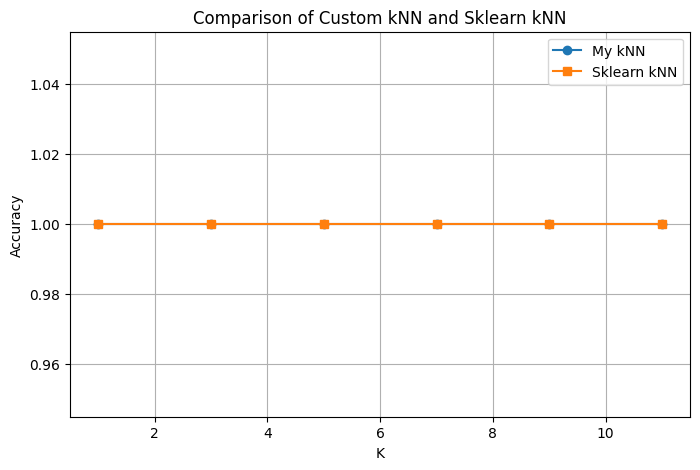

In [11]:
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

k_values = [1, 3, 5, 7, 9, 11]

my_accuracies = []
sklearn_accuracies = []

for k in k_values:

    my_model = MyKNN(k=k)
    my_model.fit(X_train, y_train)

    my_accuracy = my_model.score(
        X_test,
        y_test
    )

    my_accuracies.append(my_accuracy)

    sklearn_model = KNeighborsClassifier(
        n_neighbors=k,
        metric="cosine"
    )

    sklearn_model.fit(X_train, y_train)

    sklearn_accuracy = sklearn_model.score(
        X_test,
        y_test
    )

    sklearn_accuracies.append(sklearn_accuracy)

print("K values:", k_values)
print("My kNN accuracies:", my_accuracies)
print("Sklearn accuracies:", sklearn_accuracies)

plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    my_accuracies,
    marker="o",
    label="My kNN"
)

plt.plot(
    k_values,
    sklearn_accuracies,
    marker="s",
    label="Sklearn kNN"
)

plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("Comparison of Custom kNN and Sklearn kNN")
plt.legend()
plt.grid()
plt.show()

K values: [1, 3, 5, 7, 9, 11]
Normal kNN: [np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)]
Weighted kNN: [np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)]

Comparison:
    K  Normal kNN  Weighted kNN
0   1         1.0           1.0
1   3         1.0           1.0
2   5         1.0           1.0
3   7         1.0           1.0
4   9         1.0           1.0
5  11         1.0           1.0


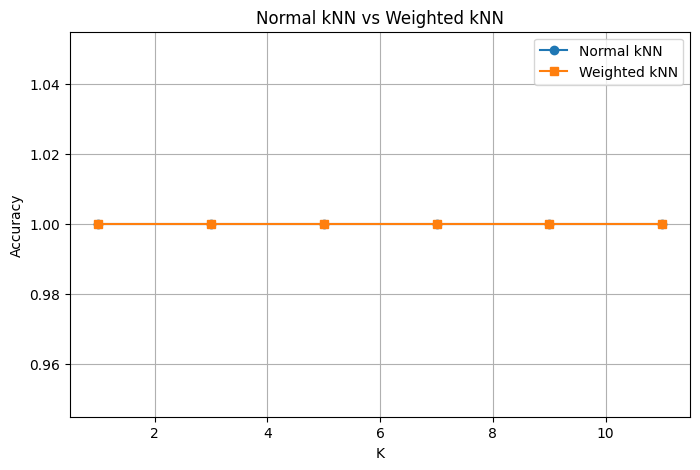

In [12]:
weighted_accuracies = []

for k in k_values:

    weighted_predictions = []

    for i in range(X_test.shape[0]):

        neighbors, distances = find_neighbors(
            X_test[i],
            X_train,
            k,
            "bubble"
        )

        prediction = weighted_vote(
            neighbors,
            distances,
            y_train
        )

        weighted_predictions.append(prediction)

    accuracy = np.mean(
        np.array(weighted_predictions) == y_test.values
    )

    weighted_accuracies.append(accuracy)

print("K values:", k_values)
print("Normal kNN:", my_accuracies)
print("Weighted kNN:", weighted_accuracies)

comparison = pd.DataFrame({
    "K": k_values,
    "Normal kNN": my_accuracies,
    "Weighted kNN": weighted_accuracies
})

print("\nComparison:")
print(comparison)

plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    my_accuracies,
    marker="o",
    label="Normal kNN"
)

plt.plot(
    k_values,
    weighted_accuracies,
    marker="s",
    label="Weighted kNN"
)

plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("Normal kNN vs Weighted kNN")
plt.legend()
plt.grid()
plt.show()